# 1.1 Acoustic Modeling Basics

This tutorial is the canonical first FrequenSolve example. It builds a two-layer acoustic model, writes a project, runs time-domain and single-frequency jobs on a local site, reads traces with `TraceDataset`, and requests ParaView output.

The example uses flat interfaces and constant per-layer material properties so the project structure, mesh controls, boundary conditions, acquisition, jobs, and outputs are easy to inspect.

By the end, you should understand the core FrequenSolve loop: build a project-owned simulation, inspect the exported inputs, run strict jobs, read traces, and request ParaView output for spatial QC.


## API Concepts

A FrequenSolve project owns simulations and jobs. A simulation contains the physical model, mesh, boundary conditions, acquisition, numerics, units, and coordinate systems. Jobs select the workflow and output requests. Sites run jobs and return handles/results.

The first three Modeling Basics notebooks intentionally use the same flat two-layer geometry and shared material values. Acoustic uses only compressional wave propagation (`Vp` and `Rho`); elastic reuses those values and adds shear-wave speed (`Vs`); poroelastic reuses the elastic frame and adds pore-fluid and transport properties. That progression makes the additional physics visible without changing the background model.

This notebook uses a free top boundary and PML on the sides and bottom. The reference tables below list the acoustic material properties and boundary-condition names accepted by the public API for this physics family.


## Modeling Workflow

This notebook follows the same pattern used throughout the tutorial collection:

1. Define the physical vocabulary: physics, units, material properties, and boundary conditions.
2. Build a small model whose geometry and properties can be inspected visually.
3. Add a mesh generator, acquisition geometry, discretization, and solver settings.
4. Save the project so the exported solver inputs can be audited.
5. Submit strict jobs, then inspect logs, traces, and ParaView output.

If you are new to the package, this is the mental model to keep: Python objects are the authoring API, project files are the solver contracts, and result handles are the bridge back to analysis objects such as `TraceDataset`.


In [1]:

import numpy as np
import frequensolve as fs

u = fs.ureg


## Project And Simulation

The project path is the root for saved JSON, HDF5 inputs, job files, logs, and results. The notebook writes into `./scratch/tutorials/simple_acoustic` so repeated runs keep generated files away from source files.


In [2]:
project = fs.Project(
    name="project",
    pretty_name="Simple Acoustic Tutorial",
    path="./scratch/tutorials/simple_acoustic",
    log_level="INFO",
    log_to_console=True,
)

sim = project.new_simulation(
    name="simple_acoustic",
    physics="acoustic",
    dimension=2,
    units={
        "length": "km",
        "velocity": "km/s",
        "density": "g/cm^3",
    },
)


## Acoustic Material Properties

Start by deciding which material properties the physics needs. Acoustic physics is the smallest supported material model: `Vp` controls compressional wave speed and wavelength, while `Rho` controls impedance and reflection strength. These `Vp` and `Rho` values are reused in the elastic and poroelastic notebooks so the early physics examples build on the same background model.

| Property | Unit | upper_layer | lower_layer | Meaning |
| --- | --- | ---: | ---: | --- |
| `Vp` | km/s | 2.0 | 2.8 | Compressional/acoustic wave speed. |
| `Rho` | g/cm^3 | 2.2 | 2.4 | Bulk mass density used with `Vp` to set acoustic impedance. |

Permissible acoustic material properties are intentionally few. Adaptivity-only fields such as `hmin`, `hmax`, and `epw_mult` are mesh controls and are covered in the meshing tutorials rather than in this material table.

| Property | Dimension | Required | Short explanation |
| --- | --- | --- | --- |
| `Vp` | L/T | Yes | Compressional/acoustic wave speed. It controls travel time and wavelength. |
| `Rho` | M/L^3 | Yes | Bulk mass density. Together with `Vp`, it controls acoustic impedance and reflection strength. |
| `Qp` | 1 | No | Compressional quality factor. Lower values add stronger attenuation; omit it for a lossless acoustic run. |


## Layered Model

The model is a flat two-layer section with a top surface, one interface, and a bottom surface. The layer order determines which properties occupy each depth interval: add a surface, add the layer below it, add the next surface, and so on. Keeping the geometry flat here makes it easier to see how projects, jobs, traces, and outputs fit together before moving on to topography and variable properties.


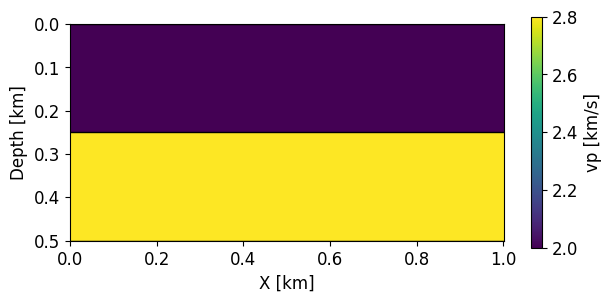

In [3]:
model = fs.LayeredModel(name="model", dimension=2, x_limits=[0.0, 1.0])
model.add_surface(name="top", depth=0.0 * u.km)
model.add_layer(
    name="upper_layer",
    properties={
        "Vp": 2.0 * u.km / u.s,
        "Rho": 2.2 * u.g / u.cm**3,
    },
)
model.add_surface(name="interface", depth=0.25 * u.km)
model.add_layer(
    name="lower_layer",
    properties={
        "Vp": 2.8 * u.km / u.s,
        "Rho": 2.4 * u.g / u.cm**3,
    },
)
model.add_surface(name="bottom", depth=0.5 * u.km)

sim += model
model.plot("vp", figsize=(7, 3), aspect="equal")


## Mesh, Order, And Wavelength Sizing

The mesh generator creates the initial geometric mesh from the model bounds and surfaces. `sim.mesh.set_adapt(...)` then tells the solver how to size the adapted mesh for the wavefield. `order` is the finite-element polynomial order. `elems_per_wave` is the requested minimum number of elements per shortest wavelength after adaptivity.

A useful first estimate for points per wavelength is `order * elems_per_wave + 1`; with `order=4` and `elems_per_wave=2`, the adapted solve has roughly nine nodal points per wavelength before details such as element family and output interpolation are considered.

The PML is not authored as an extra geological layer. When a boundary is marked `pml`, the solver auto-extrudes an absorbing layer outside that model boundary. The physical PML thickness is frequency-dependent because `pml_wavelengths` is measured in local wavelengths: lower frequencies imply longer wavelengths and therefore wider physical PMLs, while higher frequencies imply thinner physical PMLs for the same setting.


## Boundary Conditions And PML

Boundary conditions are attached after the model and mesh generator exist because they refer to named exterior boundaries such as `x_min`, `x_max`, `z_min`, and `z_max`. This notebook uses a free top boundary and PML on the side and bottom truncation boundaries.

| Boundary condition | Variables/components constrained | Typical use |
| --- | --- | --- |
| `free` | Natural/free acoustic boundary on the acoustic scalar and its normal flux trace. | Free surface or an open natural boundary when no absorbing layer is desired. |
| `fixed` | Acoustic primary scalar trace, commonly written as `p_hat`. | Hard or fixed-pressure idealization. |
| `dirichlet` | Explicitly prescribed acoustic primary scalar trace. | Advanced workflows that need an imposed boundary value. |
| `neumann` | Alias of `free` in the Python API. | Compatibility spelling for natural acoustic boundaries. |
| `impedance` | Couples the acoustic primary scalar trace with the normal flux/velocity trace through an impedance relation. | Approximate radiation or absorbing boundary without a full PML. |
| `pml` | Absorbing-layer equations for all active acoustic fields in the auto-extruded PML region. | Truncating the computational domain on sides and bottom. |
| `axis` / `symmetric` | Symmetry-axis regularity; constrains the normal component implied by the axis/symmetry formulation. | Axisymmetric or symmetry-reduced acoustic models. |

The PML settings below use `pml_wavelengths=0.75`, meaning the absorbing layer is extruded to about three quarters of a wavelength at the relevant solve frequency. `pml_reflection` defaults to `1e-3`, which is a moderate target reflection chosen to avoid making the layer unnecessarily stiff for this introductory problem. Increase `pml_wavelengths` before making the reflection target very small; overly aggressive PMLs can harm conditioning.

More complete cross-physics material and boundary tables are in the user guide page `Physics, Materials, And Boundaries`.


In [4]:
sim += model.hex_mesh_generator([8, 4])
sim.mesh.set_adapt(elems_per_wave=2.0, order=4, f_low=5.0, f_high=30.0)
sim.mesh.set_source_grading(d1=0.08, d0=0.02, mult=2.0)

sim += fs.BoundaryCondition(
    conditions=["free"],
    boundaries=["z_min"],
)
sim += fs.BoundaryCondition(
    conditions=["pml"],
    boundaries=["x_min", "x_max", "z_max"],
    pml_wavelengths=0.75,
)


## Acquisition

Sources and receivers use physical global coordinates by default. Dense receiver groups produce every requested source/receiver/component trace. Sparse surveys are covered later.


In [5]:
acq = fs.Acquisition()
acq.add_source_group(kind="scalar", coords=[[0.5, 0.025]])

hydrophone = fs.ReceiverNode(name="hydrophone")
hydrophone.add_component(name="p", field="pressure")

receiver_coords = [[x, 0.05] for x in np.linspace(0.0, 1.0, 201)]
acq.add_receiver_group(name="surface", device=hydrophone, coords=receiver_coords)
sim += acq


## Save And Inspect The Project

`site.submit(job)` saves the simulation and job automatically. Explicit saving is useful while learning because it shows the project directory structure:

- `project.json`: project manifest.
- `simulations/<simulation>/<simulation>.json`: solver simulation configuration.
- `simulations/<simulation>/<simulation>.h5`: materialized arrays when needed.
- `jobs/<simulation>/<job>/<job>.json`: job configuration.
- `jobs/<simulation>/<job>/logs`: local or fetched logs.
- `jobs/<simulation>/<job>/results`: traces, ParaView files, and run metadata.


In [6]:
project_file = project.save()
project_file


PosixPath('scratch/tutorials/simple_acoustic/project.json')

## Contract Checkpoint

A saved simulation is the right place to debug first-time setup issues. At this point the exported contract should contain these major blocks:

| Contract area | Created by | Why it matters |
| --- | --- | --- |
| `physics`, `dimension`, `Units` | `project.new_simulation(...)` | Selects the solver formulation and unit scaling. |
| `Model` | `LayeredModel` | Stores surfaces and material subdomains with canonical property names. |
| `Mesh/adapt` | `sim.mesh.set_adapt(...)` | Stores order, elements-per-wavelength, and sizing frequencies. |
| `BCs` | `fs.BoundaryCondition(...)` | Stores boundary names and PML settings. |
| `Acquisition` | `fs.Acquisition()` | Stores sources, receivers, components, coordinates, and batching. |

For remote jobs, inspect these exported blocks before spending queue time. Most setup errors are easier to find in saved JSON/HDF5 inputs than in solver logs after the fact.


## Time-Domain Job

A time-domain job is represented internally by a frequency sweep and reconstructs traces through the trace API. This cell is intentionally strict: if the local solver fails, the notebook stops and the log path printed by the exception should be inspected.


In [7]:
sim += fs.Discretization()
sim += fs.SolverConfig(tolerance=1.0e-4, grids=3)

site = fs.LocalSite(shutdown_on_completion=True, verbose=True)
job = fs.TimeDomainJob(
    name="time",
    simulation=sim,
    f_min=0.0,
    f_max=45.0,
    T_max=1.0,
)
result = site.submit(job).wait()
traces = result.traces(upscale=4)
traces.summary


2026-05-14 02:13:24,740 [INFO] frequensolve.orchestrator.sites.local:716 - Initializing Dask with 16 workers, 1 threads per worker, 7372MB memory per worker
2026-05-14 02:13:26,668 [INFO] frequensolve.orchestrator.sites.local:802 - Dask dashboard available at http://localhost:54034/status
2026-05-14 02:13:26,899 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite local:time: running


LocalSite local:time: running


Running: time 0/45 |          | Elapsed time: 00:00s

2026-05-14 02:13:30,101 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite local:time: completed


LocalSite local:time: completed


surface
  Receivers	: 1 - 201
  Shot		: 1
  Components	: ['p']
  Frequencies	: 1.00 - 45.00 Hz (Δf=1.00)
  Window	: 0.00 - 1.00 s

## Plot Traces

`RunResult.traces()` returns a `TraceDataset`. Frequency-domain reads use `traces.fd(...)`; time-domain reads use `traces.td(...)` and require a wavelet. Plotting helpers operate on normal `xarray.DataArray` objects.


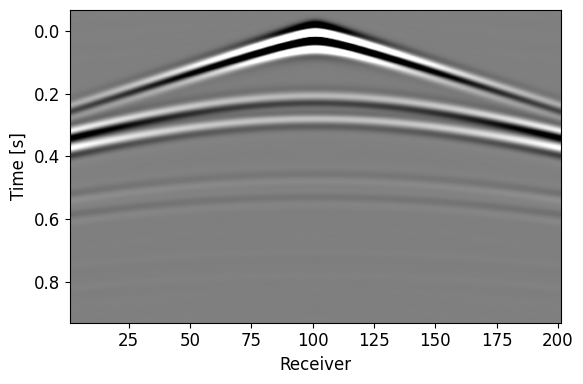

In [8]:
wavelet = fs.RickerWavelet(f=15.0)
group = traces.groups[0]
component = traces.components(group)[0]
source = traces.sources(group)[0]

gather = traces.td(group, component, source, wavelet, upscale=4)
fig, ax = fs.plot_gather(
    gather,
    A=2.0 * np.std(np.abs(gather.values)),
    cmap="gray",
    figsize=(6, 4),
)


## Single-Frequency ParaView Output

ParaView output is requested on frequency-domain jobs. The solver writes VTK files that can be opened in ParaView. Python visualization through PyVista is convenient for quick inspection, but ParaView remains the richer viewer for large meshes, multiple fields, and interactive exploration.


In [9]:
fd_job = fs.FrequencyDomainJob(
    name="freq_20hz",
    simulation=sim,
    f_list=[25.0],
    outputs=[
        fs.ParaviewOutput(
            name="pv",
            path="paraview",
            fields=["pressure", "velocity_z"],
            properties=["vp", "rho", "Subdomain"],
            show_pml=True,
            upscale=1,
            order=2,
        ),
    ],
)
fd_result = site.submit(fd_job).wait()
fd_result.output_files(base="pv", suffix=".vtu", existing=True)


2026-05-14 02:13:30,563 [INFO] frequensolve.orchestrator.sites.local:716 - Initializing Dask with 1 workers, 1 threads per worker, 7372MB memory per worker
2026-05-14 02:13:31,626 [INFO] frequensolve.orchestrator.sites.local:802 - Dask dashboard available at http://localhost:54182/status
2026-05-14 02:13:31,826 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite local:freq_20hz: running


LocalSite local:freq_20hz: running


Running: freq_20hz 0/1 |          | Elapsed time: 00:00s

2026-05-14 02:13:32,836 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite local:freq_20hz: completed


LocalSite local:freq_20hz: completed


[PosixPath('scratch/tutorials/simple_acoustic/jobs/simple_acoustic/freq_20hz/results/paraview/pv_00000.vtu'),
 PosixPath('scratch/tutorials/simple_acoustic/jobs/simple_acoustic/freq_20hz/results/ParaView/pv_00000.vtu')]

In [10]:
vtu_files = fd_result.output_files(base="pv", suffix=".vtu", existing=True)
if vtu_files:
    mesh = fs.read_vtu(vtu_files[0])
    fs.vtu_fields(mesh)[:10]


## Result Review Checklist

The acoustic tutorial is the baseline for the rest of the collection. Before moving on, confirm that the same project contains inspectable inputs, time-domain traces, and frequency-domain visualization output.

| Artifact | What it proves |
| --- | --- |
| Saved project directory | Python authoring objects exported to stable simulation/job files. |
| `traces.summary` | Receiver groups, components, source ids, and frequency coverage are discoverable through `TraceDataset`. |
| Time-domain gather | The frequency sweep and chosen Ricker wavelet reconstruct a physically readable shot record. |
| ParaView VTU files | Mesh, PML, material properties, source locations, and fields can be inspected outside Python. |
| Logs/results paths | Solver-side failures can be diagnosed without re-authoring the model. |
